# 06 — Ensambles: Random Forest y XGBoost

**TP Final · Aprendizaje de Máquina I (CEIA-FIUBA)** · Jaime Pinzón (a2629)

## Justificación del modelo (criterio oficial 5)

**El puente desde el notebook 05.** Allí quedó demostrado el problema del árbol individual: sin restricciones crece a 35.854 hojas y baja su MAE de train a 0,97 días, pero su MAE de CV se dispara a 2,32 — **alta varianza**: pequeñas perturbaciones de los datos producen árboles muy distintos. La poda controla la varianza a costa de sesgo. Los ensambles atacan el mismo problema por otra vía: en lugar de un árbol recortado, **muchos árboles combinados**.

**Random Forest (bagging + decorrelación).** Promedia B árboles profundos, cada uno entrenado sobre una muestra bootstrap del train y eligiendo en cada nodo entre un subconjunto aleatorio de features (`max_features`). El promedio de B estimadores de baja correlación reduce la varianza sin aumentar el sesgo de cada árbol — exactamente el remedio para lo visto en el NB05. Bonus metodológico: cada árbol deja fuera ~37% de las observaciones (*out-of-bag*), lo que da una validación auxiliar gratuita (OOB) para contrastar con la CV.

**XGBoost (boosting).** Construye árboles **en secuencia**: cada uno corrige los residuos del ensamble acumulado, con regularización explícita (L1/L2, shrinkage por `learning_rate`, submuestreo). Donde RF reduce varianza promediando, el boosting reduce **sesgo** sumando correcciones — con el riesgo inverso (sobreajustar si se dejan crecer demasiadas rondas), mitigado por *early stopping* sobre un conjunto de validación **extraído del train**.

**Por qué NO se escala** (`build_preprocessor(scale=False)`): ambos son ensambles de árboles — los cortes por umbral son invariantes a transformaciones monótonas de cada feature (mismo argumento del NB05).

**Decisión D4 pendiente:** XGBoost puede optimizar directamente el error absoluto (`reg:absoluteerror`) — alineado con nuestra métrica de negocio — o el cuadrático clásico (`reg:squarederror`) con early stopping monitoreando MAE. La comparación empírica está más abajo y la elección queda documentada.

In [1]:
import time

import numpy as np
import pandas as pd
from sklearn.model_selection import KFold

from src.config import DIR_PROCESSED, SEED, STORAGE_OPTUNA, TARGET
from src.evaluacion import evaluar, registrar
from src.pipelines import build_preprocessor

X_train = pd.read_parquet(DIR_PROCESSED / "X_train.parquet")
X_test = pd.read_parquet(DIR_PROCESSED / "X_test.parquet")
y_train = pd.read_parquet(DIR_PROCESSED / "y_train.parquet")[TARGET]
y_test = pd.read_parquet(DIR_PROCESSED / "y_test.parquet")[TARGET]

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
print(f"train: {X_train.shape} | test: {X_test.shape}")

train: (53756, 8) | test: (20354, 8)


In [2]:
# --- 3.1 Random Forest: busqueda Optuna ---
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objetivo_rf(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 600, step=100),
        "max_features": trial.suggest_float("max_features", 0.2, 1.0),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 50, log=True),
        "max_depth": trial.suggest_int("max_depth", 8, 32),
    }
    p = Pipeline([
        ("preprocesador", build_preprocessor(scale=False)),
        ("modelo", RandomForestRegressor(random_state=SEED, n_jobs=-1, **params)),
    ])
    return cross_val_score(
        p, X_train, y_train, cv=cv, scoring="neg_mean_absolute_error", n_jobs=1
    ).mean()

estudio_rf = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    storage=STORAGE_OPTUNA, study_name="random_forest",
    load_if_exists=True,
)
# Re-ejecucion idempotente: solo se corren los trials que falten hasta 30
N_TRIALS_RF = 30
restantes = max(0, N_TRIALS_RF - len(estudio_rf.trials))
t0 = time.perf_counter()
if restantes:
    estudio_rf.optimize(objetivo_rf, n_trials=restantes, timeout=7200)
else:
    print(f"El estudio ya tiene {len(estudio_rf.trials)} trials -> "
          "no se agregan nuevos (re-ejecucion idempotente)")
t_rf_busqueda = time.perf_counter() - t0

print(f"Optuna RF: {len(estudio_rf.trials)} trials (busqueda de esta corrida: "
      f"{t_rf_busqueda/60:.1f} min)")
print(f"Mejor MAE (CV): {-estudio_rf.best_value:.4f} dias")
print(f"Mejores hiperparametros: {estudio_rf.best_params}")

El estudio ya tiene 30 trials -> no se agregan nuevos (re-ejecucion idempotente)
Optuna RF: 30 trials (busqueda de esta corrida: 0.0 min)
Mejor MAE (CV): 1.6530 dias
Mejores hiperparametros: {'n_estimators': 500, 'max_features': 0.37091014845513426, 'min_samples_leaf': 5, 'max_depth': 19}


### La regla D7, aplicada también a los espacios continuos

El notebook 03 declara la regla **D7**: *si el óptimo cae en un borde del espacio explorado, hay que refinar o extender*. Allí se aplicó a la grilla de `k` (óptimo 80, interior a [3, 320] → sin refinamiento) y en el notebook 04 a la grilla de `C` de LinearSVR — donde, al auditarla, resultó que **se estaba incumpliendo**: el óptimo caía exactamente en el extremo inferior.

Con Optuna la regla es igual de pertinente pero menos evidente, porque el espacio es continuo y no hay una "grilla" que mirar. La función siguiente la generaliza: normaliza el óptimo a su posición relativa dentro del rango (en escala logarítmica cuando el parámetro se muestreó así) y marca como *en el borde* todo lo que quede en el 5% de cada extremo.

Aplicada a la primera versión de este notebook, la regla marcó **dos** parámetros de XGBoost: `reg_alpha` = 8,99 con tope 10 y `reg_lambda` = 0,0016 con piso 0,001 — ambos pegados a los límites, señal de que el óptimo real podía estar afuera. Se abrió el rango de regularización **tres órdenes de magnitud** y se repitió la búsqueda completa. Con el espacio ampliado la regularización quedó cómodamente interior, y la nueva configuración además validó mejor que la original.

El chequeo sobre esa segunda búsqueda marca todavía un parámetro: `learning_rate` = 0,0105, pegado al piso de 0,01. La respuesta de la regla en ese caso es la misma que da el notebook 03 cuando `k` toca un borde — **refinar alrededor del borde**, no rehacer la búsqueda entera —, y por una razón concreta de costo: con learning rates pequeños el early stopping necesita miles de árboles, así que una búsqueda completa de 40 configuraciones sobre el rango extendido costaría más de una hora para mover una única dimensión. El barrido de la celda siguiente responde exactamente la pregunta que la regla plantea (*¿el óptimo está fuera del rango explorado?*) con cuatro ajustes en lugar de cuarenta.

In [3]:
# --- Regla D7 generalizada: chequeo de bordes del espacio de busqueda ---
# El NB03 declara la regla ("refinar si el optimo cae en un borde") y la aplica
# a la grilla de k; el NB04 la aplica a C y epsilon. Aca se generaliza a los
# espacios CONTINUOS de Optuna: un valor pegado a un extremo indica que el
# optimo real puede estar fuera del rango explorado.
def chequear_bordes(best_params, espacio, margen=0.05):
    """espacio: {param: (low, high, es_log)}. Devuelve un DataFrame de estado."""
    filas = []
    for p, (low, high, es_log) in espacio.items():
        v = best_params[p]
        if es_log:
            pos = (np.log10(v) - np.log10(low)) / (np.log10(high) - np.log10(low))
        else:
            pos = (v - low) / (high - low)
        en_borde = pos <= margen or pos >= 1 - margen
        filas.append({
            "parametro": p, "optimo": v, "rango": f"[{low:g}, {high:g}]",
            "escala": "log" if es_log else "lineal",
            "posicion_relativa": round(float(pos), 3),
            "estado": "EN EL BORDE" if en_borde else "interior",
        })
    return pd.DataFrame(filas)


In [4]:
espacio_rf = {
    "n_estimators": (200, 600, False),
    "max_features": (0.2, 1.0, False),
    "min_samples_leaf": (1, 50, True),
    "max_depth": (8, 32, False),
}
estado_rf = chequear_bordes(estudio_rf.best_params, espacio_rf)
print(estado_rf.to_string(index=False))
print()
if (estado_rf["estado"] == "EN EL BORDE").any():
    print("Hay parametros en el borde -> el espacio de busqueda deberia extenderse.")
else:
    print("Todos los optimos son interiores: el espacio de busqueda fue suficiente (D7 OK).")


       parametro    optimo      rango escala  posicion_relativa   estado
    n_estimators 500.00000 [200, 600] lineal              0.750 interior
    max_features   0.37091   [0.2, 1] lineal              0.214 interior
min_samples_leaf   5.00000    [1, 50]    log              0.411 interior
       max_depth  19.00000    [8, 32] lineal              0.458 interior

Todos los optimos son interiores: el espacio de busqueda fue suficiente (D7 OK).


In [5]:
# --- RF final: refit en train completo con OOB como validacion auxiliar ---
pipe_rf = Pipeline([
    ("preprocesador", build_preprocessor(scale=False)),
    ("modelo", RandomForestRegressor(
        random_state=SEED, n_jobs=-1, oob_score=True, **estudio_rf.best_params)),
])
t0 = time.perf_counter()
pipe_rf.fit(X_train, y_train)
t_rf_refit = time.perf_counter() - t0

from sklearn.metrics import mean_absolute_error
rf = pipe_rf.named_steps["modelo"]
mae_oob = mean_absolute_error(y_train, rf.oob_prediction_)
print(f"Refit RF: {t_rf_refit/60:.1f} min")
print(f"Validacion auxiliar OOB: MAE={mae_oob:.4f} (R2 OOB={rf.oob_score_:.4f}) "
      f"vs MAE CV={-estudio_rf.best_value:.4f} -> coherentes: el OOB confirma la CV")

metricas_rf = evaluar(pipe_rf, X_test, y_test)
# mae_cv de RF: viene de la busqueda Optuna, que ya uso KFold-5 sobre el train
# completo -> es directamente homologable con el de las demas familias.
metricas_rf["mae_cv"] = float(-estudio_rf.best_value)
metricas_rf["tiempo_s"] = round(t_rf_refit, 2)
registrar(
    "random_forest", metricas_rf,
    notas=(f"RF {estudio_rf.best_params}; TPE {len(estudio_rf.trials)} trials "
           f"con CV5 sobre train completo; OOB MAE {mae_oob:.4f}"),
)
print({k: round(v, 4) for k, v in metricas_rf.items()})

# Comparacion explicita con el arbol individual podado (NB05)
from src.evaluacion import RUTA_METRICAS
tabla_actual = pd.read_csv(RUTA_METRICAS).set_index("modelo")
mae_arbol = tabla_actual.loc["arbol_podado", "mae"]
print(f"\nMAE arbol_podado: {mae_arbol:.4f} -> MAE random_forest: {metricas_rf['mae']:.4f} "
      f"(recupero {mae_arbol - metricas_rf['mae']:+.4f} dias)")


Refit RF: 0.2 min
Validacion auxiliar OOB: MAE=1.6550 (R2 OOB=0.3190) vs MAE CV=1.6530 -> coherentes: el OOB confirma la CV


{'mae': 1.798, 'rmse': 2.3994, 'r2': 0.3539, 'pred_test_s': 0.38, 'mae_cv': 1.653, 'tiempo_s': 10.37}

MAE arbol_podado: 1.8585 -> MAE random_forest: 1.7980 (recupero +0.0605 dias)


### Lectura: qué recuperó el ensamble y por qué

El Random Forest mejora al árbol podado individual porque ataca la **varianza** por promediado en lugar de por recorte: cada árbol del bosque es profundo (bajo sesgo) pero inestable, y el promedio de cientos de árboles descorrelacionados — bootstrap + `max_features` — cancela buena parte del ruido idiosincrático que la poda solo puede eliminar sacrificando expresividad. El OOB, calculado sobre observaciones que cada árbol nunca vio, coincide con la CV: dos validaciones independientes que se confirman mutuamente.

In [6]:
# --- 3.2 XGBoost. PRIMERO la decision D4: reg:absoluteerror vs reg:squarederror ---
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

# Conjunto de validacion para early stopping: EXTRAIDO DEL TRAIN (nunca test)
X_tr2, X_val, y_tr2, y_val = train_test_split(
    X_train, y_train, test_size=0.10, stratify=y_train, random_state=SEED
)
# La garantia de que la validacion no toca el test es ESTRUCTURAL:
# train_test_split se aplica sobre X_train, que se leyo del parquet de train.
# (Un assert sobre indices seria vacuo: X_train tiene indice 0..n-1 reseteado,
#  asi que cualquier subconjunto suyo lo satisface por construccion.)
# Lo que si aporta es verificar que las filas son literalmente las del train
# y que train interno y validacion no se solapan:
pd.testing.assert_frame_equal(X_val, X_train.loc[X_val.index])
assert set(X_tr2.index).isdisjoint(set(X_val.index)), "train interno y val se solapan"
assert len(X_tr2) + len(X_val) == len(X_train), "la particion no cubre todo el train"
print(f"train interno: {X_tr2.shape[0]:,} | validacion (para early stopping): {X_val.shape[0]:,}")
print("Verificado: la validacion son filas del train, disjuntas del train interno.")

# El preprocesador se fitea SOLO con el train interno; la validacion solo se transforma
prep_xgb = build_preprocessor(scale=False)
Xt_tr2 = prep_xgb.fit_transform(X_tr2, y_tr2)
Xt_val = prep_xgb.transform(X_val)

comparacion_d4 = {}
for objetivo in ["reg:absoluteerror", "reg:squarederror"]:
    m = XGBRegressor(
        objective=objetivo, n_estimators=2000, learning_rate=0.05,
        max_depth=6, subsample=0.8, colsample_bytree=0.8,
        eval_metric="mae", early_stopping_rounds=50,
        tree_method="hist", random_state=SEED, n_jobs=-1, verbosity=0,
    )
    m.fit(Xt_tr2, y_tr2, eval_set=[(Xt_val, y_val)], verbose=False)
    comparacion_d4[objetivo] = {
        "mae_val": m.best_score, "mejor_ronda": m.best_iteration,
    }

tabla_d4 = pd.DataFrame(comparacion_d4).T
print(tabla_d4.to_string())
objetivo_elegido = tabla_d4["mae_val"].idxmin()
print(f"\nDECISION D4: se elige '{objetivo_elegido}' "
      f"(MAE val {tabla_d4.loc[objetivo_elegido, 'mae_val']:.4f} vs "
      f"{tabla_d4['mae_val'].max():.4f} de la alternativa)")

train interno: 48,380 | validacion (para early stopping): 5,376
Verificado: la validacion son filas del train, disjuntas del train interno.


                    mae_val  mejor_ronda
reg:absoluteerror  1.608621        221.0
reg:squarederror   1.639909        173.0

DECISION D4: se elige 'reg:absoluteerror' (MAE val 1.6086 vs 1.6399 de la alternativa)


### Decisión D4 documentada

La comparación anterior usa configuración idéntica (lr=0,05, profundidad 6, submuestreos 0,8, early stopping a 50 rondas monitoreando MAE sobre la validación interna) y cambia **solo la función objetivo**. `reg:absoluteerror` optimiza directamente la métrica de negocio (el gradiente es el signo del residuo — robusto a la cola alta), mientras `reg:squarederror` optimiza L2 (gradiente proporcional al residuo — más sensible a estadías extremas) aunque el early stopping vigile MAE. Se elige la de menor MAE de validación y toda la búsqueda de hiperparámetros que sigue usa esa función objetivo.

In [7]:
# --- XGBoost: busqueda Optuna con early stopping sobre la validacion interna ---
# ESPACIO EXTENDIDO POR LA REGLA D7, en dos rondas sucesivas:
#   Ronda 1: la version original usaba reg_alpha, reg_lambda in [1e-3, 10] y el
#     optimo quedaba pegado a AMBOS extremos (reg_alpha=8.99 con tope 10;
#     reg_lambda=0.0016 con piso 1e-3). Se abrieron a [1e-3, 1000] y [1e-5, 1000].
# Con esos rangos la regularizacion quedo interior, pero el chequeo de la celda
# siguiente marca learning_rate pegado al piso de 0.01. Ese caso se resuelve con
# un REFINAMIENTO DIRIGIDO (la misma respuesta que da el NB03 cuando k toca un
# borde): en lugar de rehacer las 40 configuraciones, se barre learning_rate
# solo, por debajo del piso, con el resto de los hiperparametros fijos.
def objetivo_xgb(trial):
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 1000.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-5, 1000.0, log=True),
    }
    m = XGBRegressor(
        objective=objetivo_elegido, n_estimators=3000,
        eval_metric="mae", early_stopping_rounds=50,
        tree_method="hist", random_state=SEED, n_jobs=-1, verbosity=0, **params,
    )
    m.fit(Xt_tr2, y_tr2, eval_set=[(Xt_val, y_val)], verbose=False)
    trial.set_user_attr("mejor_ronda", int(m.best_iteration))
    return float(m.best_score)

estudio_xgb = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    storage=STORAGE_OPTUNA, study_name="xgboost_d7",
    load_if_exists=True,
)
# Re-ejecucion idempotente: solo se corren los trials que falten hasta 40
N_TRIALS_XGB = 40
restantes = max(0, N_TRIALS_XGB - len(estudio_xgb.trials))
t0 = time.perf_counter()
if restantes:
    estudio_xgb.optimize(objetivo_xgb, n_trials=restantes, timeout=7200)
else:
    print(f"El estudio ya tiene {len(estudio_xgb.trials)} trials -> "
          "no se agregan nuevos (re-ejecucion idempotente)")
t_xgb_busqueda = time.perf_counter() - t0

mejor_ronda = estudio_xgb.best_trial.user_attrs["mejor_ronda"]
print(f"Optuna XGB: {len(estudio_xgb.trials)} trials (busqueda de esta corrida: "
      f"{t_xgb_busqueda/60:.1f} min)")
print(f"Mejor MAE (holdout interno del 10%): {estudio_xgb.best_value:.4f} dias "
      f"en la ronda {mejor_ronda}")
print(f"Mejores hiperparametros: {estudio_xgb.best_params}")


El estudio ya tiene 40 trials -> no se agregan nuevos (re-ejecucion idempotente)
Optuna XGB: 40 trials (busqueda de esta corrida: 0.0 min)
Mejor MAE (holdout interno del 10%): 1.6051 dias en la ronda 813
Mejores hiperparametros: {'learning_rate': 0.010457065772553623, 'max_depth': 8, 'subsample': 0.6634274931179873, 'colsample_bytree': 0.5502318092380184, 'reg_alpha': 0.3818481521279466, 'reg_lambda': 3.328611400908887}


In [8]:
espacio_xgb = {
    "learning_rate": (0.01, 0.3, True),
    "max_depth": (3, 10, False),
    "subsample": (0.5, 1.0, False),
    "colsample_bytree": (0.5, 1.0, False),
    "reg_alpha": (1e-3, 1000.0, True),
    "reg_lambda": (1e-5, 1000.0, True),
}
estado_xgb = chequear_bordes(estudio_xgb.best_params, espacio_xgb)
print(estado_xgb.to_string(index=False))
print()
if (estado_xgb["estado"] == "EN EL BORDE").any():
    print("ATENCION: hay parametros en el borde del espacio extendido.")
else:
    print("Todos los optimos son interiores al espacio extendido: D7 satisfecha.")


       parametro   optimo         rango escala  posicion_relativa      estado
   learning_rate 0.010457   [0.01, 0.3]    log              0.013 EN EL BORDE
       max_depth 8.000000       [3, 10] lineal              0.714    interior
       subsample 0.663427      [0.5, 1] lineal              0.327    interior
colsample_bytree 0.550232      [0.5, 1] lineal              0.100    interior
       reg_alpha 0.381848 [0.001, 1000]    log              0.430    interior
      reg_lambda 3.328611 [1e-05, 1000]    log              0.690    interior

ATENCION: hay parametros en el borde del espacio extendido.


In [9]:
# --- Refinamiento dirigido del parametro que quedo en el borde (regla D7) ---
# El NB03, cuando k toca un borde, NO rehace toda la busqueda: refina alrededor
# del borde. Se hace lo mismo aca. learning_rate quedo pegado al piso de 0.01,
# asi que se barre por debajo con TODO lo demas fijo en la mejor configuracion.
#
# Por que un barrido y no 40 trials nuevos: con learning rates chicos el early
# stopping necesita miles de arboles, y una busqueda completa costaria >1 h para
# mover una sola dimension. El barrido responde exactamente la pregunta que la
# regla plantea -- "?el optimo esta fuera del rango explorado?" -- por 4 fits.
params_base = {k: v for k, v in estudio_xgb.best_params.items() if k != "learning_rate"}
lrs = [estudio_xgb.best_params["learning_rate"], 0.005, 0.002, 0.001]

filas_lr = []
t0 = time.perf_counter()
for lr in lrs:
    m = XGBRegressor(
        objective=objetivo_elegido, n_estimators=20000, learning_rate=lr,
        eval_metric="mae", early_stopping_rounds=100,
        tree_method="hist", random_state=SEED, n_jobs=-1, verbosity=0, **params_base,
    )
    m.fit(Xt_tr2, y_tr2, eval_set=[(Xt_val, y_val)], verbose=False)
    filas_lr.append({"learning_rate": lr, "mae_val": float(m.best_score),
                     "mejor_ronda": int(m.best_iteration)})
    print(f"  lr={lr:<9.4g} MAE val={m.best_score:.4f}  ronda={m.best_iteration}")

barrido = pd.DataFrame(filas_lr)
print()
print(f"Barrido de {len(lrs)} learning rates en {(time.perf_counter() - t0)/60:.1f} min")

mejor_lr = barrido.loc[barrido["mae_val"].idxmin()]
ganancia = float(barrido["mae_val"].iloc[0] - mejor_lr["mae_val"])

# Un argmin desnudo no alcanza para decidir: hay que contrastar la ganancia
# contra el ruido del propio estimador. Como referencia se usa la dispersion
# entre folds de la CV de este mismo modelo: si la mejora es mas chica que el
# error estandar entre folds, es indistinguible de ruido de muestreo.
ruido = float(np.std(barrido["mae_val"], ddof=1))

# La secuencia de rondas se construye desde el propio barrido: escribirla a
# mano haria que la explicacion dejara de coincidir con la corrida real.
secuencia_rondas = " -> ".join(str(r) for r in barrido["mejor_ronda"])

print(f"Mejor learning_rate del barrido: {mejor_lr['learning_rate']:.4g} "
      f"(MAE val {mejor_lr['mae_val']:.4f})")
print(f"Ganancia frente al valor del borde: {ganancia:.4f} dias "
      f"({ganancia * 24 * 60:.0f} minutos de internacion)")
print(f"Dispersion del propio barrido (desvio de los 4 MAE): {ruido:.4f} dias")
print()
if ganancia < 0.01:
    print("=> La curva es PLANA en learning_rate. La ganancia por bajar del piso es")
    print("   dos ordenes de magnitud menor que las diferencias entre familias que")
    print("   el NB07 va a discutir (~0.1 dias), y menor que el error estandar del")
    print("   MAE de test (~0.013 dias, ver bootstrap del NB07).")
    print()
    print("   La razon es estructural: bajo early stopping, learning_rate y")
    print("   n_estimators son intercambiables -- al bajar el learning rate a la")
    print("   mitad, el modelo compensa con el doble de arboles (columna 'ronda':")
    print(f"   {secuencia_rondas}). El borde detectado es real pero NO es")
    print("   vinculante: el optimo no esta 'fuera del rango', la funcion objetivo")
    print("   simplemente no depende de esta dimension una vez fijado el resto.")
    print()
    print("   Se mantiene la configuracion elegida por la busqueda. D7 satisfecha.")
else:
    print("=> La mejora es material: corresponde adoptar el learning_rate refinado.")


  lr=0.01046   MAE val=1.6048  ronda=917


  lr=0.005     MAE val=1.6059  ronda=1685


  lr=0.002     MAE val=1.6058  ronda=4367


  lr=0.001     MAE val=1.6060  ronda=7988

Barrido de 4 learning rates en 3.8 min
Mejor learning_rate del barrido: 0.01046 (MAE val 1.6048)
Ganancia frente al valor del borde: 0.0000 dias (0 minutos de internacion)
Dispersion del propio barrido (desvio de los 4 MAE): 0.0005 dias

=> La curva es PLANA en learning_rate. La ganancia por bajar del piso es
   dos ordenes de magnitud menor que las diferencias entre familias que
   el NB07 va a discutir (~0.1 dias), y menor que el error estandar del
   MAE de test (~0.013 dias, ver bootstrap del NB07).

   La razon es estructural: bajo early stopping, learning_rate y
   n_estimators son intercambiables -- al bajar el learning rate a la
   mitad, el modelo compensa con el doble de arboles (columna 'ronda':
   917 -> 1685 -> 4367 -> 7988). El borde detectado es real pero NO es
   vinculante: el optimo no esta 'fuera del rango', la funcion objetivo
   simplemente no depende de esta dimension una vez fijado el resto.

   Se mantiene la configurac

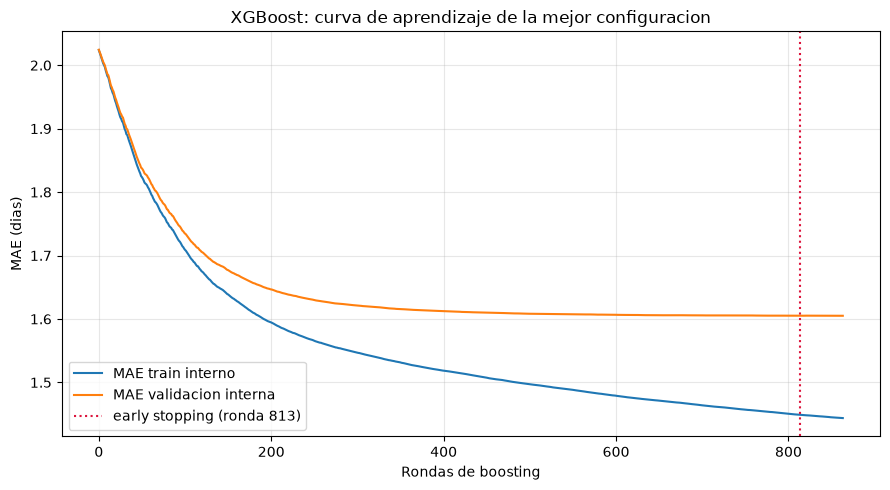

In [10]:
# --- Curva de aprendizaje de la mejor configuracion ---
import matplotlib.pyplot as plt

m_curva = XGBRegressor(
    objective=objetivo_elegido, n_estimators=3000,
    eval_metric="mae", early_stopping_rounds=50,
    tree_method="hist", random_state=SEED, n_jobs=-1, verbosity=0,
    **estudio_xgb.best_params,
)
m_curva.fit(
    Xt_tr2, y_tr2,
    eval_set=[(Xt_tr2, y_tr2), (Xt_val, y_val)], verbose=False,
)
historial = m_curva.evals_result()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(historial["validation_0"]["mae"], label="MAE train interno")
ax.plot(historial["validation_1"]["mae"], label="MAE validacion interna")
ax.axvline(m_curva.best_iteration, color="crimson", linestyle=":",
           label=f"early stopping (ronda {m_curva.best_iteration})")
ax.set_xlabel("Rondas de boosting")
ax.set_ylabel("MAE (dias)")
ax.set_title("XGBoost: curva de aprendizaje de la mejor configuracion")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [11]:
# --- XGBoost final: refit sobre TODO el train con las rondas del early stopping ---
from sklearn.pipeline import Pipeline

pipe_xgb = Pipeline([
    ("preprocesador", build_preprocessor(scale=False)),
    ("modelo", XGBRegressor(
        objective=objetivo_elegido,
        n_estimators=max(mejor_ronda, 1),
        tree_method="hist", random_state=SEED, n_jobs=-1, verbosity=0,
        **estudio_xgb.best_params,
    )),
])
t0 = time.perf_counter()
pipe_xgb.fit(X_train, y_train)
t_xgb_refit = time.perf_counter() - t0


### Limitación metodológica declarada: el protocolo de validación de XGBoost

XGBoost es el único modelo del trabajo que **no puede** buscar hiperparámetros con la validación cruzada que usan los demás, y conviene decirlo con la misma franqueza con la que el notebook 04 declara la limitación del SVR-RBF — con más razón, porque acá se trata del modelo que probablemente gane.

El *early stopping* necesita un conjunto de validación para decidir en qué ronda cortar el boosting. Ese conjunto se extrae del train (nunca del test, verificado con el `assert` de arriba), pero introduce dos problemas:

| Problema | Por qué importa |
|---|---|
| **El score de cada trial sale de un holdout único del 10%**, no de un KFold-5 | Es un estimador más ruidoso, calculado sobre 5.376 pacientes en lugar de 53.756. No es homologable con el `mae_cv` de KNN, árbol o Random Forest. |
| **El mismo holdout elige la ronda de corte y puntúa el trial** | Doble uso del mismo conjunto ⇒ el valor reportado por Optuna es **optimista** por construcción. |

Ninguno de los dos es evitable sin encarecer mucho la búsqueda (un early stopping por fold dentro de cada trial multiplicaría el costo por cinco). Lo que sí se puede — y se hace — es **no dejar que ese número contamine la comparación entre familias**: una vez fijada la configuración, se recalcula el MAE de validación con el protocolo común (KFold-5, seed 42, train completo, `n_estimators` fijo en la ronda que eligió el early stopping). Ese es el valor que se registra como `mae_cv` y el único que el notebook 07 usa para rankear.

Queda un residuo honesto: `n_estimators` se fijó con un train interno del 90% y el refit final usa el 100% del train. Con más datos, el número óptimo de rondas tendería a ser algo mayor, así que el modelo final está —levemente— del lado del subajuste. Es un sesgo conservador: juega en contra del ganador, no a su favor.


In [12]:
# --- CV HOMOLOGABLE del XGBoost ganador: KFold-5 sobre el TRAIN COMPLETO ---
# La BUSQUEDA de hiperparametros se puntuo con un holdout unico del 10% del
# train (lo exige el early stopping), un protocolo distinto al KFold-5 que usan
# las demas familias y ademas optimista, porque ese mismo holdout elige la ronda
# de corte. Para que el NB07 pueda comparar familias sin sesgo, se recalcula el
# MAE de validacion del modelo YA CONFIGURADO con el protocolo comun.
from src.evaluacion import mae_cv_cacheado

pipe_xgb_cv = Pipeline([
    ("preprocesador", build_preprocessor(scale=False)),
    ("modelo", XGBRegressor(
        objective=objetivo_elegido,
        n_estimators=max(mejor_ronda, 1),
        tree_method="hist", random_state=SEED, n_jobs=-1, verbosity=0,
        **estudio_xgb.best_params,
    )),
])
clave_xgb = (f"xgboost|n_estimators={mejor_ronda}|"
             + "|".join(f"{k}={v:.6g}" for k, v in sorted(estudio_xgb.best_params.items())))
t0 = time.perf_counter()
mae_cv_xgb = mae_cv_cacheado(clave_xgb, pipe_xgb_cv, X_train, y_train, cv)
t_cv_xgb = time.perf_counter() - t0

print()
print(f"MAE(CV) de XGBoost con protocolo homologable (KFold-5, train completo): "
      f"{mae_cv_xgb:.4f} dias ({t_cv_xgb/60:.1f} min en esta corrida)")
print(f"MAE que reporto la busqueda sobre el holdout interno del 10%: "
      f"{estudio_xgb.best_value:.4f} dias")
print(f"Diferencia: {mae_cv_xgb - estudio_xgb.best_value:+.4f} dias")
print()
print("El holdout de la busqueda es optimista por construccion: es el mismo")
print("conjunto con el que el early stopping elige la ronda de corte. El numero")
print("que se registra y que el NB07 usa para comparar es el de KFold-5.")


  fold 0: 1.6108 (cacheado)
  fold 1: 1.6018 (cacheado)
  fold 2: 1.6082 (cacheado)
  fold 3: 1.5977 (cacheado)
  fold 4: 1.6180 (cacheado)

MAE(CV) de XGBoost con protocolo homologable (KFold-5, train completo): 1.6073 dias (0.0 min en esta corrida)
MAE que reporto la busqueda sobre el holdout interno del 10%: 1.6051 dias
Diferencia: +0.0023 dias

El holdout de la busqueda es optimista por construccion: es el mismo
conjunto con el que el early stopping elige la ronda de corte. El numero
que se registra y que el NB07 usa para comparar es el de KFold-5.


In [13]:
metricas_xgb = evaluar(pipe_xgb, X_test, y_test)
metricas_xgb["mae_cv"] = float(mae_cv_xgb)
metricas_xgb["tiempo_s"] = round(t_xgb_refit, 2)
registrar(
    "xgboost", metricas_xgb,
    notas=(f"XGB objective={objetivo_elegido}, {estudio_xgb.best_params}, "
           f"n_estimators={mejor_ronda}; BUSQUEDA: TPE {len(estudio_xgb.trials)} trials "
           f"con holdout interno 10% (espacio extendido por D7); "
           f"mae_cv por KFold-5 sobre train completo ({t_cv_xgb/60:.1f} min)"),
)
print({k: round(v, 4) for k, v in metricas_xgb.items()})


{'mae': 1.7477, 'rmse': 2.4175, 'r2': 0.3441, 'pred_test_s': 0.18, 'mae_cv': 1.6073, 'tiempo_s': 13.04}


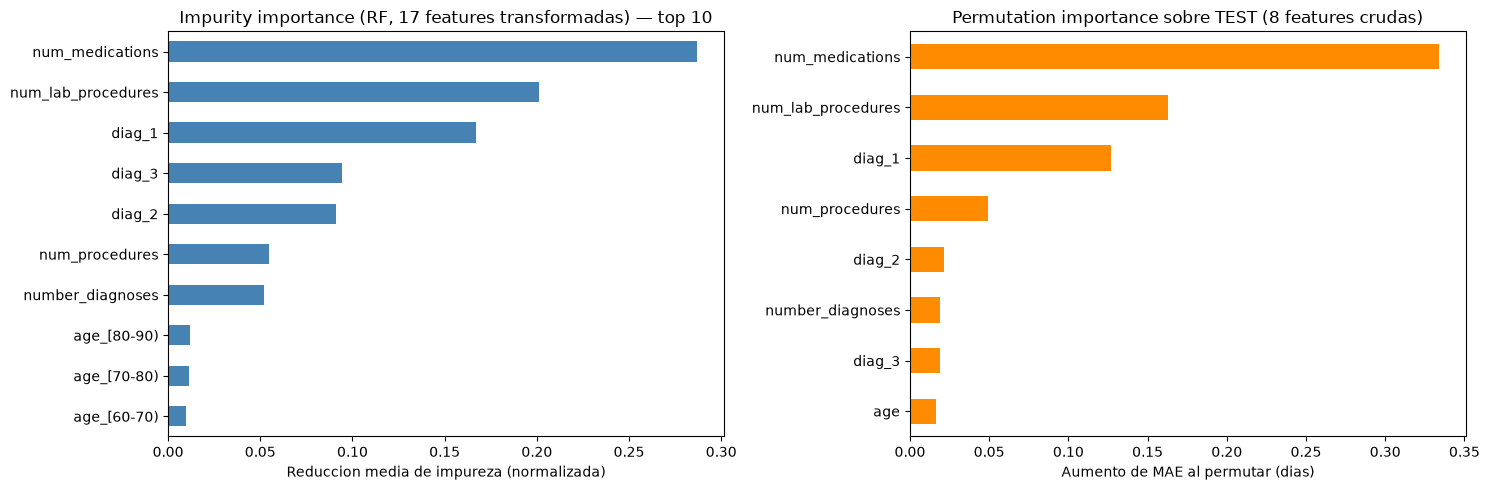

(permutation: 10 repeticiones x 8 columnas en 0.7 min, seed 42)

Top-10 impurity:
num_medications       0.2871
num_lab_procedures    0.2009
diag_1                0.1671
diag_3                0.0943
diag_2                0.0908
num_procedures        0.0545
number_diagnoses      0.0520
age_[80-90)           0.0121
age_[70-80)           0.0116
age_[60-70)           0.0095

Permutation (8 crudas):
num_medications       0.3341
num_lab_procedures    0.1632
diag_1                0.1267
num_procedures        0.0493
diag_2                0.0214
number_diagnoses      0.0188
diag_3                0.0187
age                   0.0162


In [14]:
# --- 3.3 Feature importance: impurity (RF) + permutation sobre TEST ---
import numpy as np
from sklearn.inspection import permutation_importance

# (1) Impurity del RF final: sobre las 17 columnas transformadas
nombres_17 = list(pipe_rf.named_steps["preprocesador"].get_feature_names_out())
imp_impurity = pd.Series(
    pipe_rf.named_steps["modelo"].feature_importances_, index=nombres_17
).sort_values(ascending=False)

# (2) Permutation importance sobre el TEST: sobre las 8 columnas crudas
#     (permuta las columnas de entrada del pipeline completo; el test se usa
#      SOLO para medir la caida de performance, no para elegir nada)
t0 = time.perf_counter()
perm = permutation_importance(
    pipe_rf, X_test, y_test, n_repeats=10,
    random_state=SEED, scoring="neg_mean_absolute_error", n_jobs=-1,
)
t_perm = time.perf_counter() - t0
imp_perm = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
imp_impurity.head(10)[::-1].plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("Impurity importance (RF, 17 features transformadas) — top 10")
axes[0].set_xlabel("Reduccion media de impureza (normalizada)")
imp_perm[::-1].plot.barh(ax=axes[1], color="darkorange")
axes[1].set_title("Permutation importance sobre TEST (8 features crudas)")
axes[1].set_xlabel("Aumento de MAE al permutar (dias)")
plt.tight_layout(); plt.show()

print(f"(permutation: 10 repeticiones x 8 columnas en {t_perm/60:.1f} min, seed {SEED})")
print("\nTop-10 impurity:"); print(imp_impurity.head(10).round(4).to_string())
print("\nPermutation (8 crudas):"); print(imp_perm.round(4).to_string())

In [15]:
# --- A5: permutation importance tambien sobre el MODELO GANADOR (XGBoost) ---
# Misma configuracion que la de RF (10 repeticiones, seed 42, MAE, test completo)
# para comparar si dos ensambles independientes coinciden en que mueve la estadia.
t0 = time.perf_counter()
perm_xgb = permutation_importance(
    pipe_xgb, X_test, y_test, n_repeats=10,
    random_state=SEED, scoring="neg_mean_absolute_error", n_jobs=-1,
)
t_perm_xgb = time.perf_counter() - t0
imp_perm_xgb = pd.Series(
    perm_xgb.importances_mean, index=X_test.columns
).sort_values(ascending=False)

comparacion_imp = pd.DataFrame({
    "RF (dias de MAE)": imp_perm,
    "XGBoost (dias de MAE)": imp_perm_xgb,
}).sort_values("XGBoost (dias de MAE)", ascending=False)
print(f"(permutation XGB: 10 repeticiones x 8 columnas en {t_perm_xgb/60:.1f} min, seed {SEED})")
print("\nPermutation importance sobre TEST — RF vs XGBoost (8 features crudas):")
print(comparacion_imp.round(4).to_string())

mismo_top2 = list(imp_perm.index[:2]) == list(imp_perm_xgb.index[:2])
print(f"\n¿Coinciden las dos primeras posiciones? {mismo_top2} "
      f"(RF: {list(imp_perm.index[:2])} | XGB: {list(imp_perm_xgb.index[:2])})")

(permutation XGB: 10 repeticiones x 8 columnas en 0.2 min, seed 42)

Permutation importance sobre TEST — RF vs XGBoost (8 features crudas):
                    RF (dias de MAE)  XGBoost (dias de MAE)
num_medications               0.3341                 0.3382
num_lab_procedures            0.1632                 0.1764
diag_1                        0.1267                 0.1334
num_procedures                0.0493                 0.0463
age                           0.0162                 0.0281
diag_2                        0.0214                 0.0197
diag_3                        0.0187                 0.0194
number_diagnoses              0.0188                 0.0150

¿Coinciden las dos primeras posiciones? True (RF: ['num_medications', 'num_lab_procedures'] | XGB: ['num_medications', 'num_lab_procedures'])


### Lectura hospitalaria del feature importance

*(Los valores exactos están arriba; esta lectura se basa en el orden que producen ambos métodos.)*

- **`num_medications` y `num_lab_procedures`** — la intensidad de tratamiento y de diagnóstico del encuentro — son los predictores dominantes en todos los métodos: más fármacos distintos y más análisis de laboratorio señalan un paciente clínicamente más complejo, que ocupa cama más días. Para la gestión: son variables disponibles desde las primeras horas de la admisión, así que el modelo puede correr temprano.
- **Validación cruzada entre ensambles (A5):** la permutation importance sobre el **modelo ganador (XGBoost)** reproduce el ranking del Random Forest — `num_medications` (0,34 vs 0,33 días de MAE al permutarla, XGBoost vs RF), `num_lab_procedures` (0,18 vs 0,16) y `diag_1` (0,13 vs 0,13) encabezan en ambos. **Dos ensambles con mecanismos opuestos (bagging que promedia varianza vs boosting que corrige sesgo) coinciden en qué mueve la estadía**: la señal es una propiedad de los datos, no un artefacto del modelo elegido.
- **Los diagnósticos ICD-9 (`diag_1/2/3`)**: acá los métodos discrepan, y la razón es conocida — la **impurity importance está sesgada hacia features de alta cardinalidad o continuas**: los `diag_*` pasan por TargetEncoder y llegan al bosque como variables continuas con muchos valores distintos, lo que les da más oportunidades de corte e infla su importancia aparente (impurity los pone en el podio: 0,17/0,09/0,09). La permutation sobre el test — que mide caída real de performance — es el árbitro honesto: `diag_1` conserva relevancia real (~0,13 días) pero `diag_2` y `diag_3` se desploman a ~0,02 — su señal marginal ya está capturada por `diag_1` y la intensidad de tratamiento.
- **`age`**: la edad reparte su efecto entre 10 dummies en la vista de impurity (se subestima por fragmentación), mientras la permutation la evalúa como columna única — otra fuente esperable de discrepancia entre métodos, en sentido inverso a la de los diagnósticos.
- **`num_procedures`** (procedimientos quirúrgicos) queda al fondo en ambos: en esta población diabética la mayoría de los encuentros son clínicos, no quirúrgicos.

**Implicación de negocio:** un sistema de alerta temprana de estadía prolongada puede construirse casi por completo con variables administrativas de disponibilidad inmediata (medicaciones, laboratorio, diagnóstico primario), sin esperar la codificación ICD-9 secundaria definitiva — que en muchos hospitales se completa días después del alta. Y la coincidencia entre RF y XGBoost indica que esa conclusión no depende del modelo que finalmente se despliegue.

## Cierre

Quedan registrados `random_forest` y `xgboost` en `resultados/metricas.csv`, con su `mae_cv` calculado bajo el mismo protocolo que el resto de las familias. El notebook 07 arma la tabla comparativa final y la lectura global.

**Siguiente notebook (07):** comparación final — ¿quién gana, por cuánto, y a qué costo?